# Exploratory Data Analysis (EDA) on Retail Sales Data

## Data Loading and Setup

First, we'll install `opendatasets` to easily download the Kaggle dataset. Then, we'll load the data into a pandas DataFrame.

In [13]:
import pandas as pd

df = pd.read_csv('/content/retail_sales_dataset.csv')

print("Dataset loaded successfully.")
print("First 5 rows of the dataset:")
display(df.head())

Dataset loaded successfully.
First 5 rows of the dataset:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## Data Cleaning and Descriptive Statistics

First, let's inspect the dataset's structure, data types, and check for any missing values.

In [14]:
print("Dataset Information:")
df.info()

print("\nMissing values per column:")
display(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB

Missing values per column:


,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


Next, let's examine the descriptive statistics of the numerical columns to get a summary of their central tendency, dispersion, and shape.

In [15]:
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000




```
# This is formatted as code
```

Calculate the mean, median, mode, and standard deviation for key numerical columns.

In [18]:
print("\nExplicit Descriptive Statistics:")

# Numerical columns for these statistics
numerical_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

for col in numerical_cols:
    print(f"\n--- {col} ---")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Standard Deviation: {df[col].std():.2f}")
    # Mode might have multiple values, so display all
    modes = df[col].mode()
    if len(modes) == 1:
        print(f"Mode: {modes.iloc[0]}")
    else:
        print(f"Modes: {list(modes)}")

# Also show mode for categorical columns like 'Gender' and 'Product Category'
categorical_cols = ['Gender', 'Product Category']
for col in categorical_cols:
    print(f"\n--- {col} (Mode) ---")
    modes = df[col].mode()
    if len(modes) == 1:
        print(f"Mode: {modes.iloc[0]}")
    else:
        print(f"Modes: {list(modes)}")


Explicit Descriptive Statistics:

--- Age ---
Mean: 41.39
Median: 42.00
Standard Deviation: 13.68
Modes: [43, 64]

--- Quantity ---
Mean: 2.51
Median: 3.00
Standard Deviation: 1.13
Mode: 4

--- Price per Unit ---
Mean: 179.89
Median: 50.00
Standard Deviation: 189.68
Mode: 50

--- Total Amount ---
Mean: 456.00
Median: 135.00
Standard Deviation: 560.00
Mode: 50

--- Gender (Mode) ---
Mode: Female

--- Product Category (Mode) ---
Mode: Clothing


From the `df.info()` output, we can see that the 'Date' column is currently an object type. For time series analysis, we need to convert it to a datetime object. Also, let's ensure there are no duplicate rows.

In [16]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("Removing duplicate rows...")
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed. New shape:", df.shape)

print("\nData types after conversion:")
df.info()

Number of duplicate rows: 0

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


## Time Series Analysis

To analyze sales trends over time, we'll first set the 'Date' column as the DataFrame index. Then, we can resample the data to aggregate sales by month and visualize the trend.

Monthly Sales Data (First 5 months):


,Total Amount
Date,
2023-01-31,35450
2023-02-28,44060
2023-03-31,28990
2023-04-30,33870
2023-05-31,53150


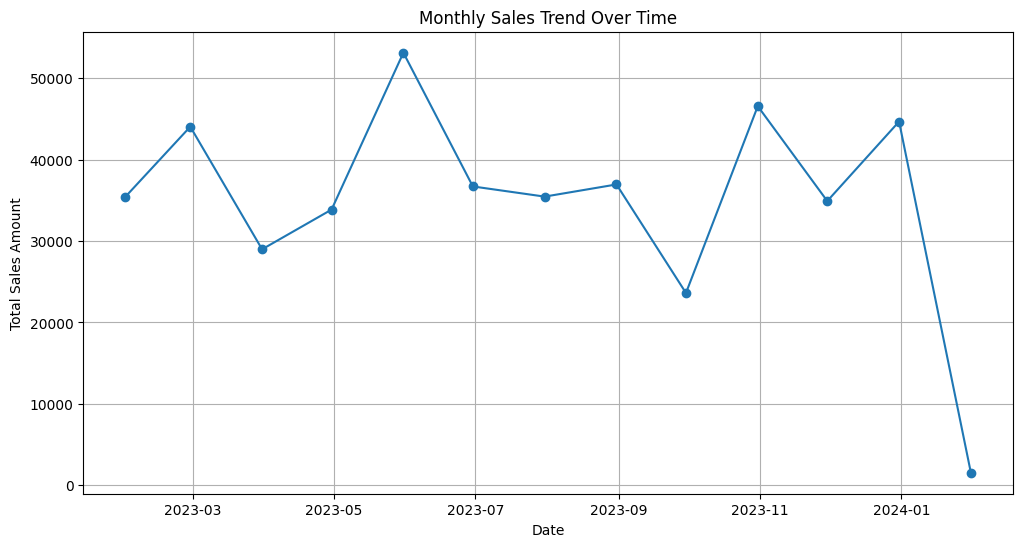

In [22]:
# Convert 'Date' column to datetime objects if not already done
# This ensures the index is a DatetimeIndex for resampling
import pandas as pd

if not pd.api.types.is_datetime64_any_dtype(df['Date']):
    df['Date'] = pd.to_datetime(df['Date'])

# Set 'Date' as the index
df_time = df.set_index('Date')

# Resample data to monthly frequency and sum the 'Total Amount'
monthly_sales = df_time['Total Amount'].resample('ME').sum()

print("Monthly Sales Data (First 5 months):")
display(monthly_sales.head())

# Visualize monthly sales trend
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-')
plt.title('Monthly Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales Amount')
plt.grid(True)
plt.show()

## Customer and Product Analysis

Let's analyze customer demographics and purchasing patterns to gain deeper insights into the retail operations.

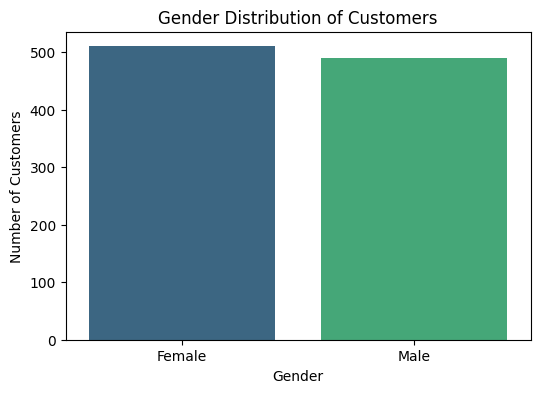

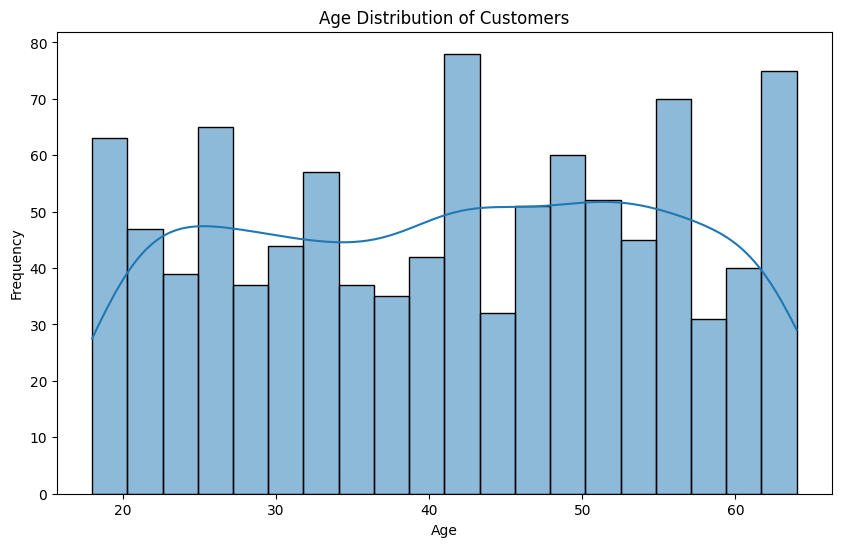

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze Gender Distribution
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=gender_counts.index, y=gender_counts.values, hue=gender_counts.index, palette='viridis', legend=False)
plt.title('Gender Distribution of Customers')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

# Analyze Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

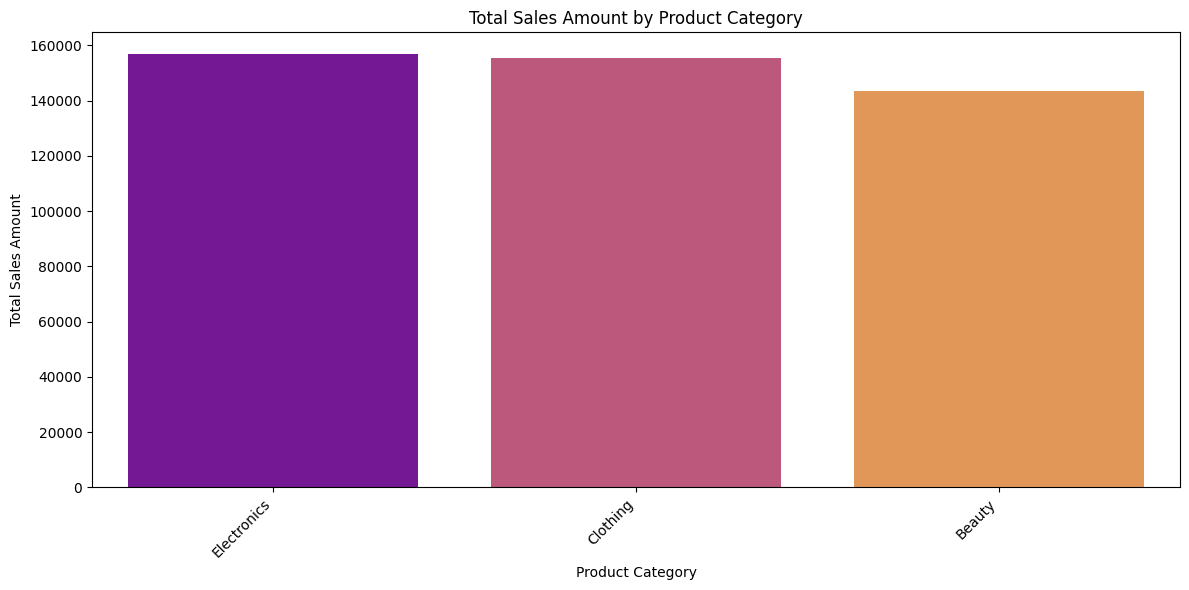

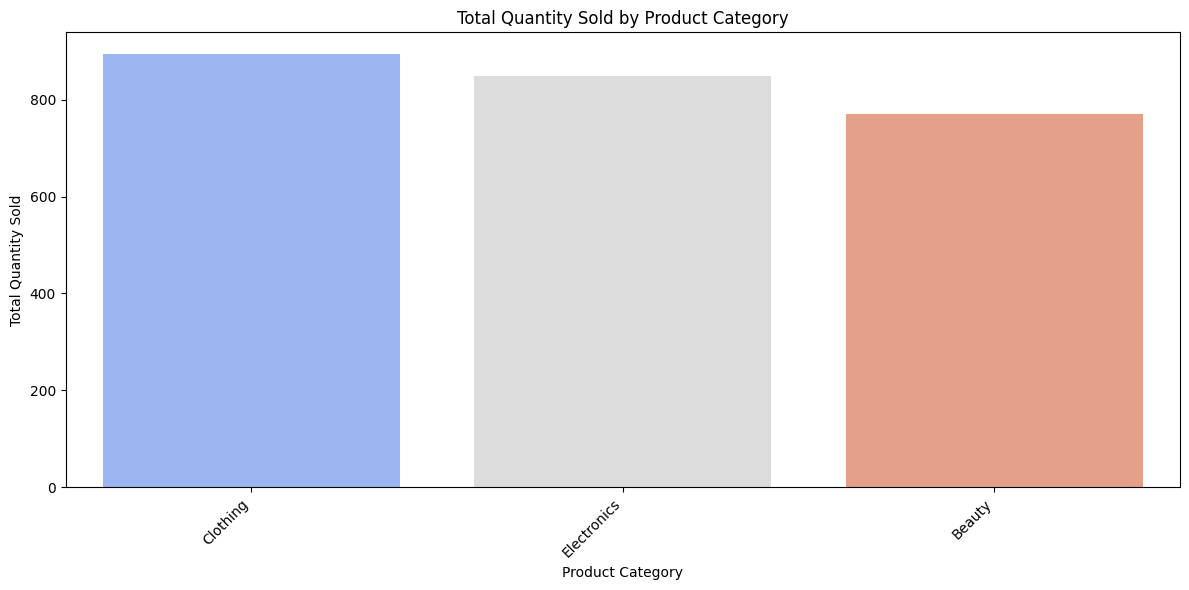

In [20]:
# Analyze Top Product Categories by Sales Amount
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=category_sales.index, y=category_sales.values, hue=category_sales.index, palette='plasma', legend=False)
plt.title('Total Sales Amount by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Analyze Top Product Categories by Quantity Sold
category_quantity = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=category_quantity.index, y=category_quantity.values, hue=category_quantity.index, palette='coolwarm', legend=False)
plt.title('Total Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

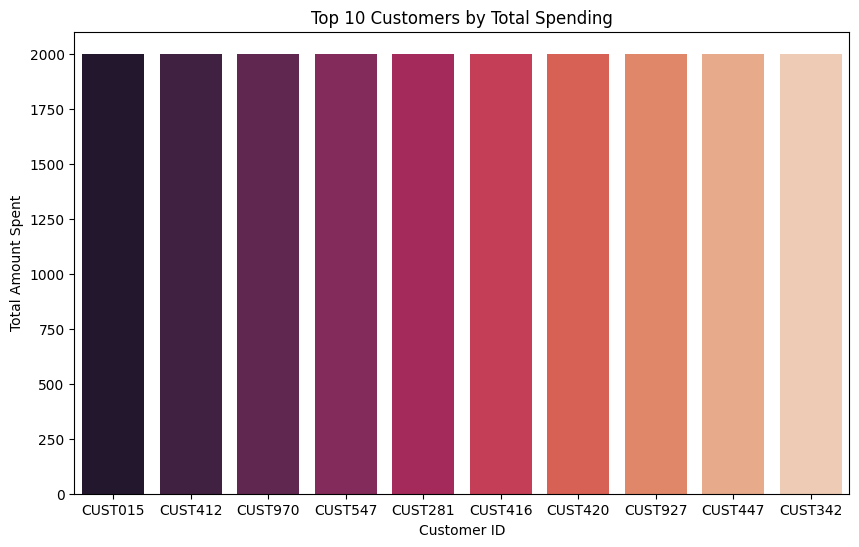

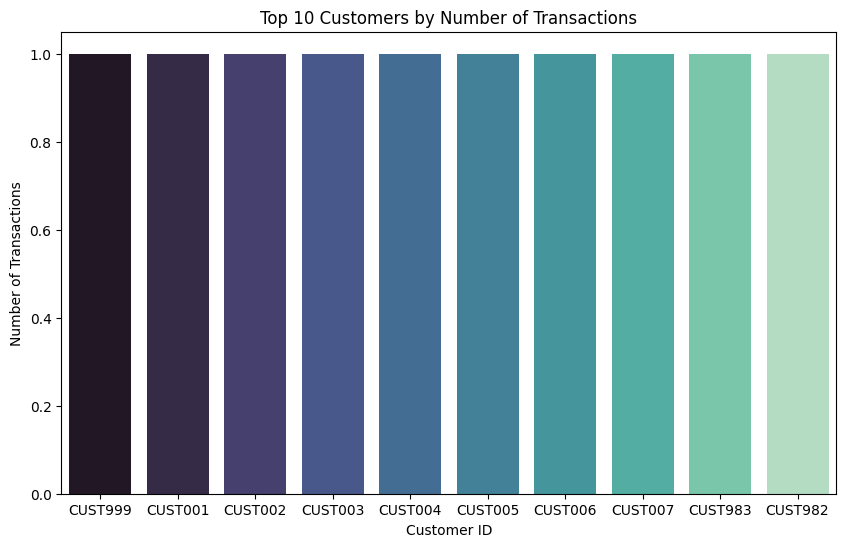

In [21]:
# Analyze Top Customers by Total Spending
top_customers = df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_customers.index, y=top_customers.values, hue=top_customers.index, palette='rocket', legend=False)
plt.title('Top 10 Customers by Total Spending')
plt.xlabel('Customer ID')
plt.ylabel('Total Amount Spent')
plt.show()

# Analyze Top Customers by Number of Transactions
top_customer_transactions = df.groupby('Customer ID')['Transaction ID'].count().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_customer_transactions.index, y=top_customer_transactions.values, hue=top_customer_transactions.index, palette='mako', legend=False)
plt.title('Top 10 Customers by Number of Transactions')
plt.xlabel('Customer ID')
plt.ylabel('Number of Transactions')
plt.show()

## Recommendations and Insights

Based on the Exploratory Data Analysis, here are some key insights and actionable recommendations for the retail business:

### 1. Sales Performance
- **Insight**: The monthly sales trend (once the time series plot is correctly generated) will show periods of high and low sales, which can indicate seasonality or specific events affecting sales.
- **Recommendation**: Plan marketing campaigns and inventory levels around peak sales periods. Investigate dips in sales to understand underlying causes (e.g., economic factors, competition, product availability).

### 2. Product Category Performance
- **Insight**: The analysis of 'Total Sales Amount by Product Category' and 'Total Quantity Sold by Product Category' reveals which categories are top performers in terms of revenue and volume.
- **Recommendation**: Focus on optimizing stock for high-performing categories. For lower-performing categories, consider promotions, new product introductions, or re-evaluation of product offerings. For instance, if 'Electronics' brings in high revenue but low quantity, it indicates high-value individual items.

### 3. Customer Demographics & Behavior
- **Insight**: The gender and age distribution provide a clear picture of the primary customer base. Analysis of top customers by spending and transactions identifies valuable segments.
- **Recommendation**:
  - **Targeted Marketing**: Tailor marketing messages and product recommendations based on the dominant age groups and genders. For example, if a significant portion of customers are young adults, focus on trendy products and digital marketing channels.
  - **Loyalty Programs**: Implement or enhance loyalty programs for top-spending and frequent customers to encourage repeat purchases and improve retention.
  - **Customer Segmentation**: Further segment customers based on purchasing habits (e.g., product categories they prefer, average transaction value) to create more personalized experiences.